LSTM model with 5 feature (Open, High, Low, Close, Volume)

Target: Future Close Price

Most recently hypertuned on 17-03-2026

Importing all the necessary Libraries 

In [16]:
#Standard library
import os
import random
from datetime import datetime, timedelta

#Data manipulation and numerical computing
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [17]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [18]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2026-03-16")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Define feature 
features = ['Close', 'Open', 'High', 'Low', 'Volume']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
feature_data = data[features].values
datetime_index = data['Date'].values

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_22900\3360157524.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2026-03-16")
[*********************100%***********************]  1 of 1 completed


In [19]:
# Get the number of close prices
print(f"Number of close prices: {len(feature_data)}")

Number of close prices: 2815


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [20]:
total_size = len(feature_data)

train_size = int(len(feature_data) * 0.70)
val_size   = int(len(feature_data) * 0.15)

train_data = feature_data[:train_size]
val_data = feature_data[train_size:train_size + val_size]
test_data = feature_data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_data)} samples ({len(train_data)/total_size:.2%})")
print(f"Validation set : {len(val_data)} samples ({len(val_data)/total_size:.2%})")
print(f"Test set       : {len(test_data)} samples ({len(test_data)/total_size:.2%})")

print("Train:", train_data.shape)
print("Val  :", val_data.shape)
print("Test :", test_data.shape)

print("\nCheck sum:", len(train_data) + len(val_data) + len(test_data))

Total samples: 2815

Dataset sizes:
Training set   : 1970 samples (69.98%)
Validation set : 422 samples (14.99%)
Test set       : 423 samples (15.03%)
Train: (1970, 5)
Val  : (422, 5)
Test : (423, 5)

Check sum: 2815


Normalizing my data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks. Need to Scale BOTH features

In [21]:
#We are now scaling the data feature wise to ensure all features contribute meaningfully
num_features = train_data.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

# Fit scalers on training data only
for i, scaler in enumerate(scalers):
    scaler.fit(train_data[:, [i]])

# Function to scale data using all scalers
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

# Transform all splits
train_scaled = scale_data(train_data, scalers)
val_scaled = scale_data(val_data, scalers)
test_scaled = scale_data(test_data, scalers)

print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("Val   scaled min/max:", val_scaled.min(), val_scaled.max())
print("Test  scaled min/max:", test_scaled.min(), test_scaled.max())

Train scaled min/max: 0.0 1.0
Val   scaled min/max: -0.027889103643613328 1.2951980316966811
Test  scaled min/max: -0.03798690807817774 1.695720044009833


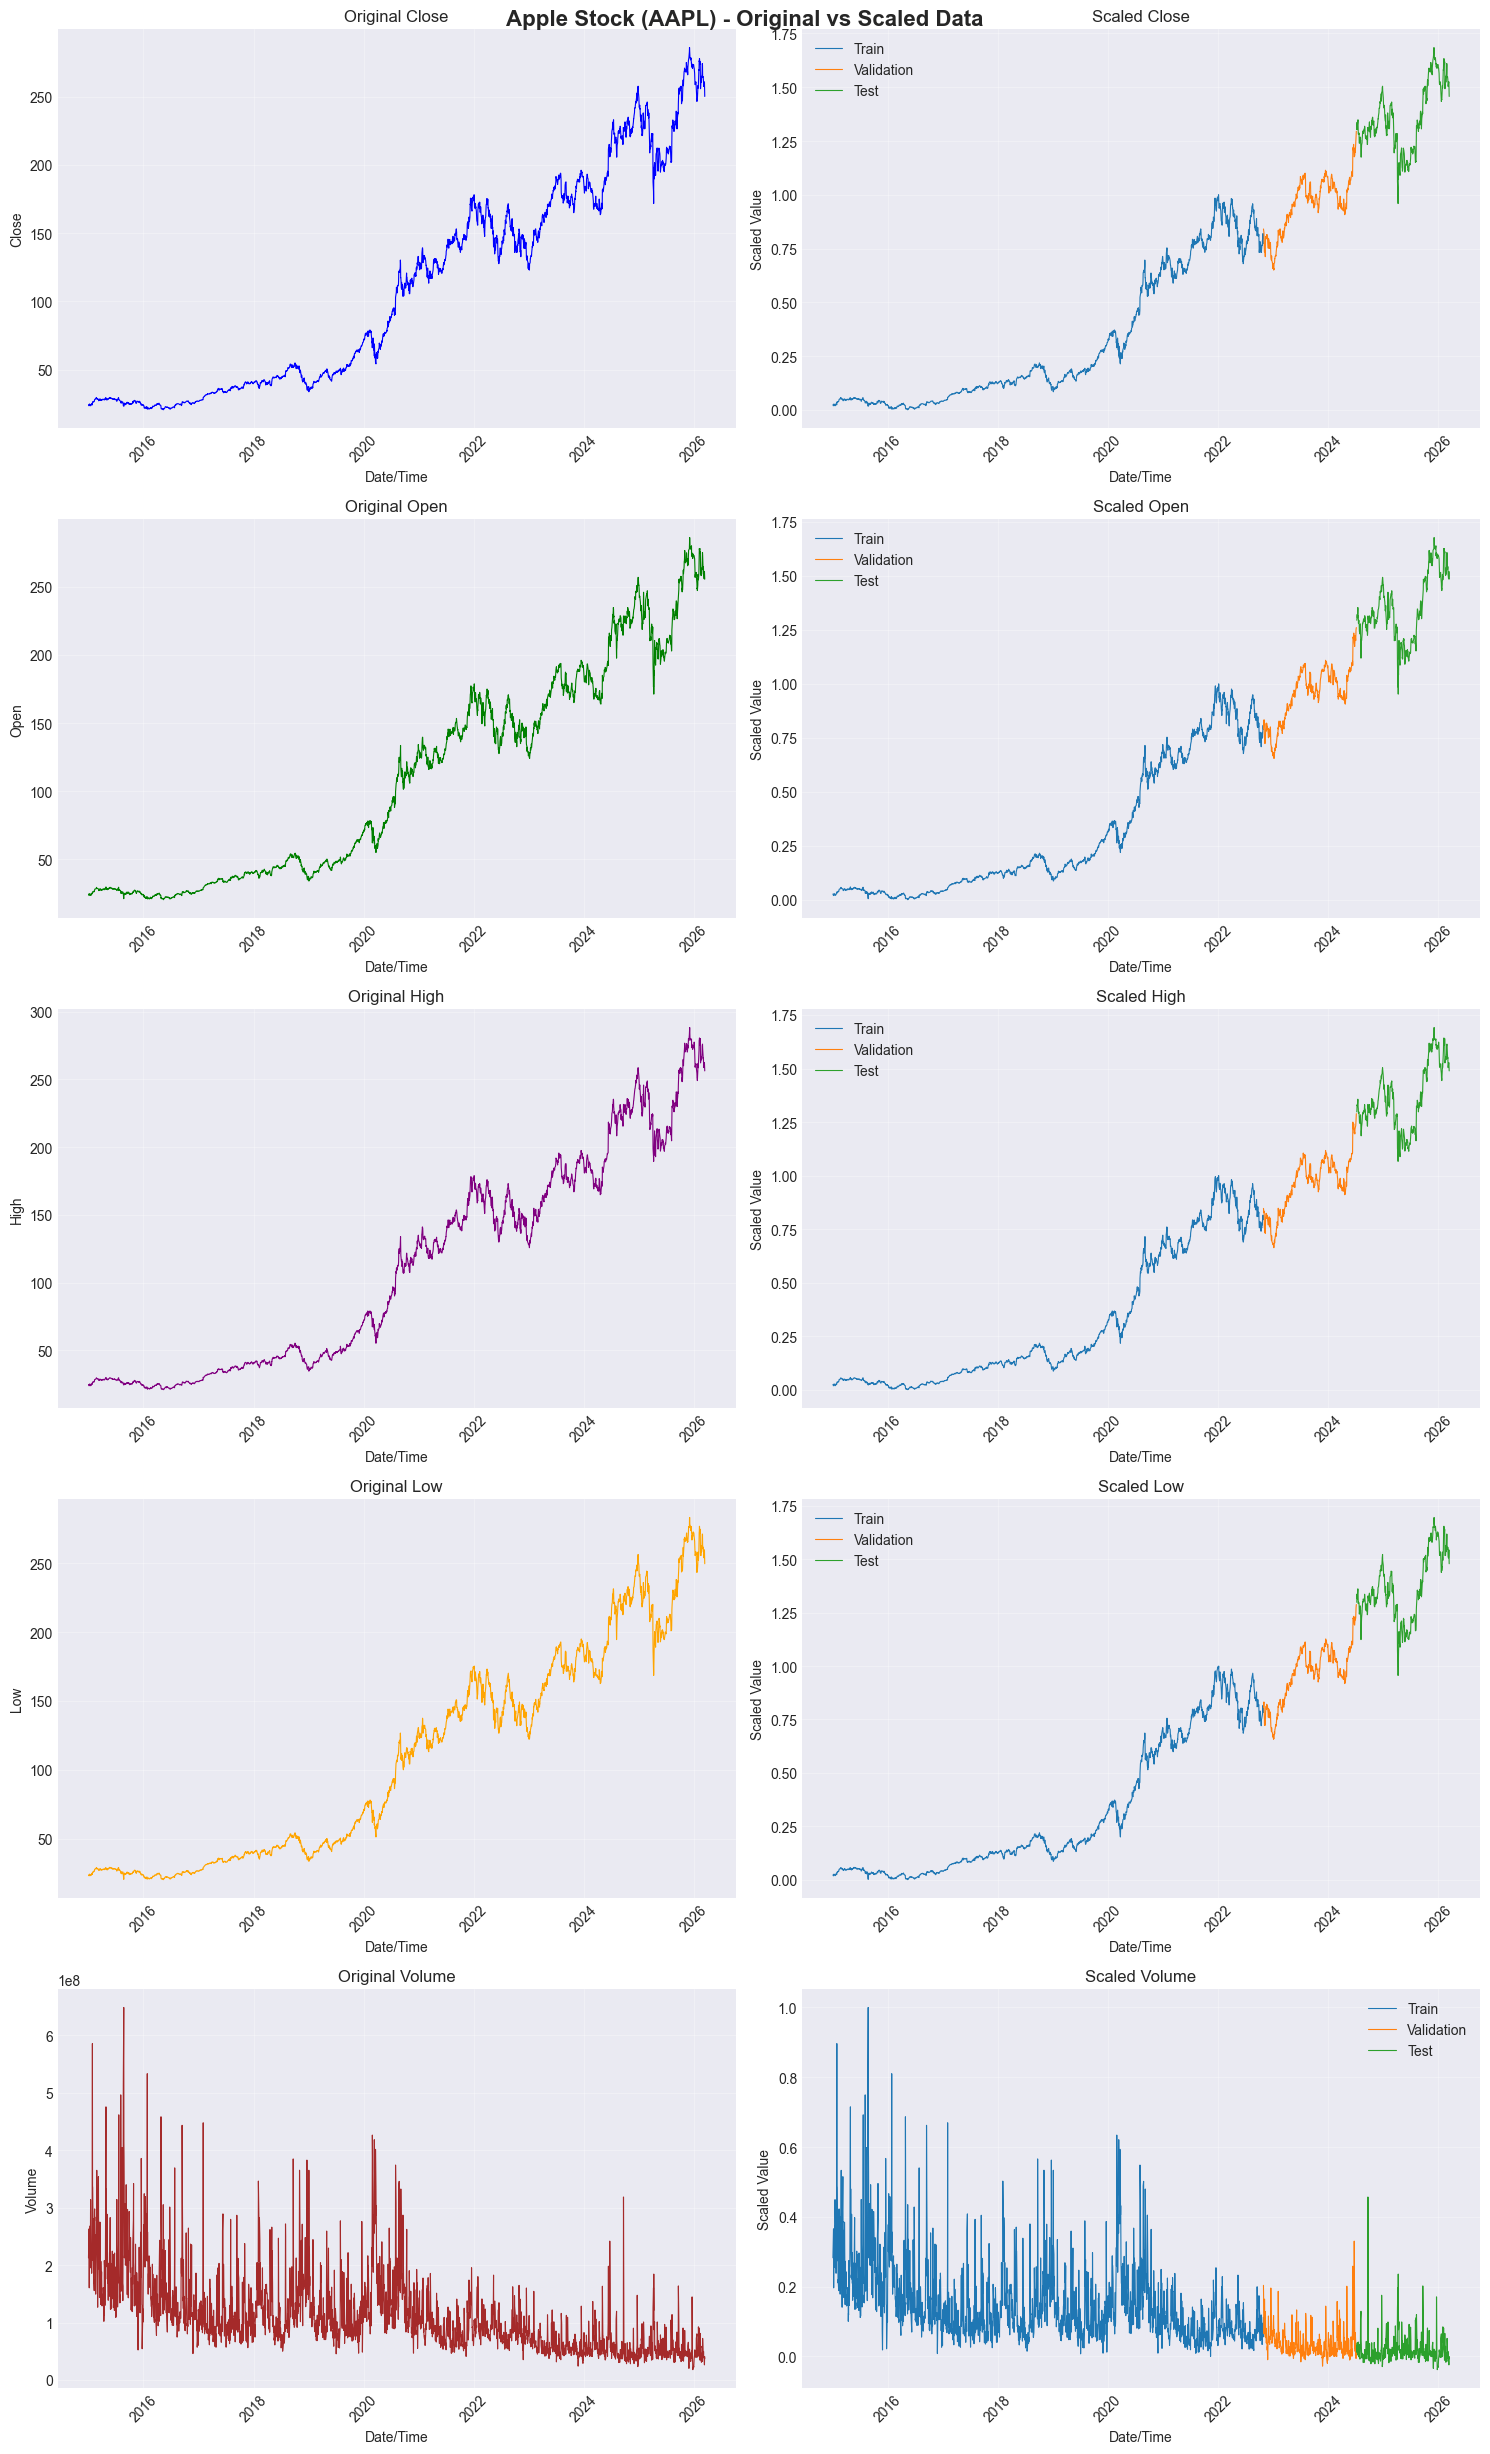

In [22]:
# Reconstructing datetime splits to match data splits
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_data.shape[1]

# Create 5x2 subplot layout for both features
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume']
colors = ['blue', 'green', 'purple', 'orange', 'brown']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, feature_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

Creating a Slidng Window to prepare the input data for the LSTM model

In [23]:
def create_multifeature_dataset_with_context(data, time_step, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-24 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 25)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_scaled, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_scaled, time_step, context_data=train_scaled)
X_test, y_test   = create_multifeature_dataset_with_context(test_scaled, time_step, context_data=val_scaled)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (1945, 25, 5), y_train: (1945,)
X_val  : (422, 25, 5), y_val  : (422,)
X_test : (423, 25, 5), y_test : (423,)


Building and Training the model

In [24]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add((LSTM(units=96, return_sequences=False, kernel_regularizer=l2(0.005))))
model.add(Dropout(0.2))

model.add(Dense(units=1))

#compile the model
model.compile(optimizer=Adam(learning_rate=5e-4), loss='mean_squared_error', metrics=['MAE'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          
    patience=3,         
    verbose=1            
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150,
    batch_size=96,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - MAE: 0.0887 - loss: 0.0563 - val_MAE: 0.0610 - val_loss: 0.0450 - learning_rate: 5.0000e-04
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1429 - loss: 0.0673 - val_MAE: 0.0846 - val_loss: 0.0434 - learning_rate: 5.0000e-04
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - MAE: 0.1290 - loss: 0.0539 - val_MAE: 0.1581 - val_loss: 0.0569 - learning_rate: 5.0000e-04
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1396 - loss: 0.0621 - val_MAE: 0.2113 - val_loss: 0.0736 - learning_rate: 5.0000e-04
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - MAE: 0.0665 - loss: 0.0338 - val_MAE: 0.0281 - val_loss: 0.0251 - learning_rate: 5.0000e-04
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - MAE: 0.0605 - loss: 0.0309 - val_MAE: 0.1219 - val_loss: 0.0379 - learning_rate: 5.0000e-04
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.0414 - loss: 0.0241 - val_MAE: 0.0272 - val_loss: 0.0205 - lear

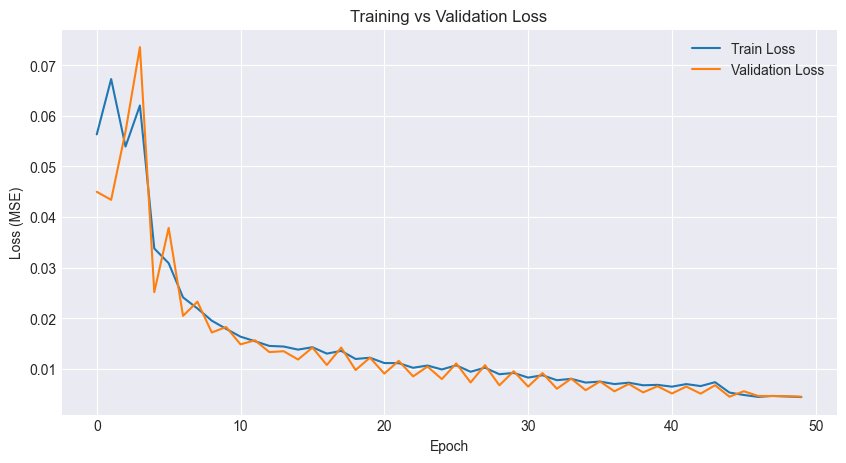

In [25]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [26]:
#This gets the predictions from the model - but these are scaled from (0-1 range) beacuse the model was trained on scaled data
predictions_scaled = model.predict(X_test)

# Inverse transform reverses the scaling applied earlier and converts predictions from 0-1 range back to actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

# Flatten the 2D array back to 1D arrays which is easier for metrics calculations
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

# Calculate metrics on unscaled data
#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Unscaled Root Mean Squared Error (RMSE): $9.14
Unscaled Mean Absolute Error (MAE): $7.36


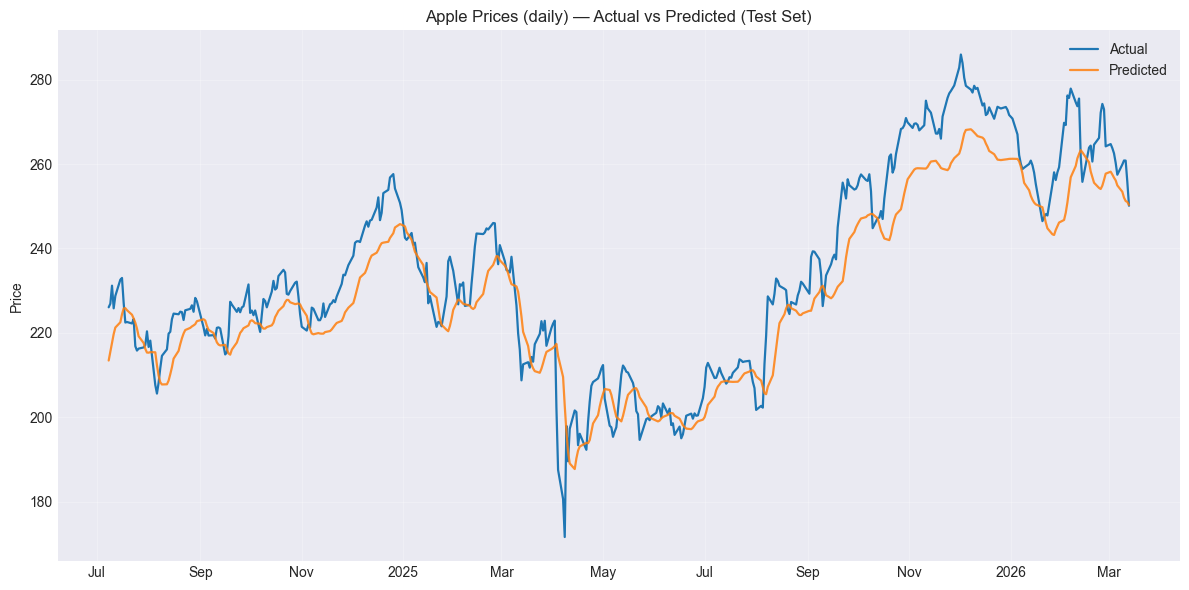

In [27]:
dates_test = datetime_index[-len(predictions):]

#Plot with real dates on the x-axis
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled.flatten(), label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions.flatten(), label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Checking the Accuracy of my model:

In [28]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 50.47%


In [29]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 3.08%
MAPE-based Accuracy: 96.92%
